In [19]:
print("Predicting earthquake magnitude")

Predicting earthquake magnitude


1. IMPORT LIBRARIES

In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib
import warnings

warnings.filterwarnings("ignore")

plt.style.use("ggplot")
sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


2. LOAD AND MERGE DATASETS

In [21]:
data_1 = pd.read_csv('../dataset/earthquake_dataset.csv')
data_2 = pd.read_csv('../dataset/earthquake_dataset_2.csv')

data = pd.concat(
    [data_1, data_2],
    ignore_index=True
)

earth_df = pd.DataFrame(data)
print('Dataset loaded successfully')

earth_df.head()

Dataset loaded successfully


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN


3. DATASET INFORMATION


In [22]:
# Column names
print("\nColumns:")
print(earth_df.columns)

# Dataset info
print("\nDataset Info:")
print(earth_df.info())


Columns:
Index(['title', 'magnitude', 'date_time', 'cdi', 'mmi', 'alert', 'tsunami',
       'sig', 'net', 'nst', 'dmin', 'gap', 'magType', 'depth', 'latitude',
       'longitude', 'location', 'continent', 'country'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 1782 entries, 0 to 1781
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1782 non-null   str    
 1   magnitude  1782 non-null   float64
 2   date_time  1782 non-null   str    
 3   cdi        1782 non-null   int64  
 4   mmi        1782 non-null   int64  
 5   alert      864 non-null    str    
 6   tsunami    1782 non-null   int64  
 7   sig        1782 non-null   int64  
 8   net        1782 non-null   str    
 9   nst        1782 non-null   int64  
 10  dmin       1782 non-null   float64
 11  gap        1782 non-null   float64
 12  magType    1782 non-null   str    
 13  depth      1782 non-null   float64
 14  latitud

In [23]:
# Shape
print("Dataset Shape:")
print(earth_df.shape)

# Missing values
print("\nMissing Values:")
print(earth_df.isnull().sum())

Dataset Shape:
(1782, 19)

Missing Values:
title           0
magnitude       0
date_time       0
cdi             0
mmi             0
alert         918
tsunami         0
sig             0
net             0
nst             0
dmin            0
gap             0
magType         0
depth           0
latitude        0
longitude       0
location       11
continent    1292
country       647
dtype: int64


Dropping un-necessary columns

In [24]:
drop_columns = [
    'title', 
    'date_time', 
    'alert', 
    'location', 
    'continent', 
    'country', 
    'net', 
    'magType'
    ]

earth_df.drop(
    columns=drop_columns,
    inplace = True,
    errors = 'ignore'
)
print(earth_df.head())
print(earth_df.isnull().sum())
earth_df.to_csv('new_dataset.csv')

   magnitude  cdi  mmi  tsunami  sig  nst      dmin    gap    depth  latitude  \
0        6.5    7    4        0  657  114  7.177000   25.0  192.955  -13.8814   
1        6.5    8    6        0  775   92  0.679000   40.0   69.727   12.8140   
2        6.6    7    5        0  899   70  1.634000   28.0  171.371  -38.1911   
3        7.2    6    6        1  860  173  0.907000   36.0   32.571   54.3844   
4        7.3    0    5        1  820   79  0.879451  172.8   21.000   54.4900   

   longitude  
0   167.1580  
1   -88.1265  
2   -70.3731  
3  -160.6990  
4  -160.7960  
magnitude    0
cdi          0
mmi          0
tsunami      0
sig          0
nst          0
dmin         0
gap          0
depth        0
latitude     0
longitude    0
dtype: int64


ALERT DISTRIBUTION

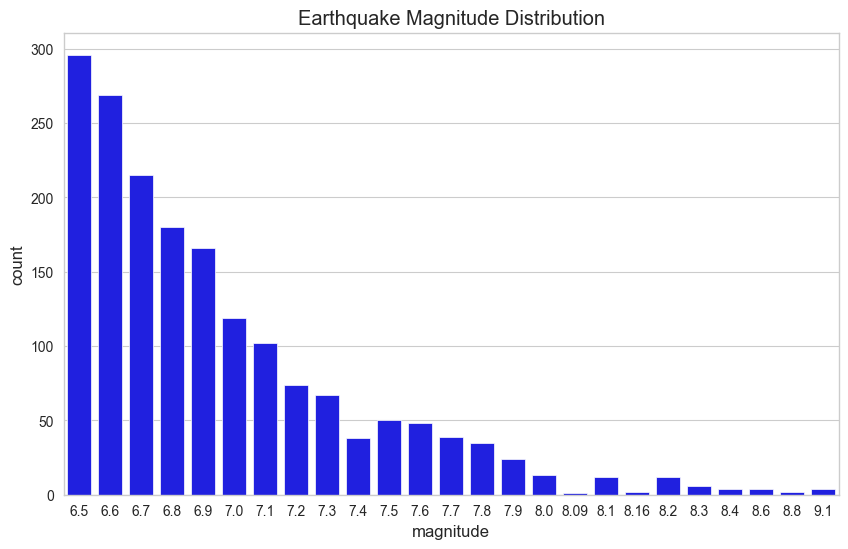

In [25]:
plt.figure(figsize=(10, 6))
sns.countplot(x="magnitude", data=earth_df, color="blue")
plt.title('Earthquake Magnitude Distribution')
plt.show()

SIGNIFICANCE DISTRIBUTION

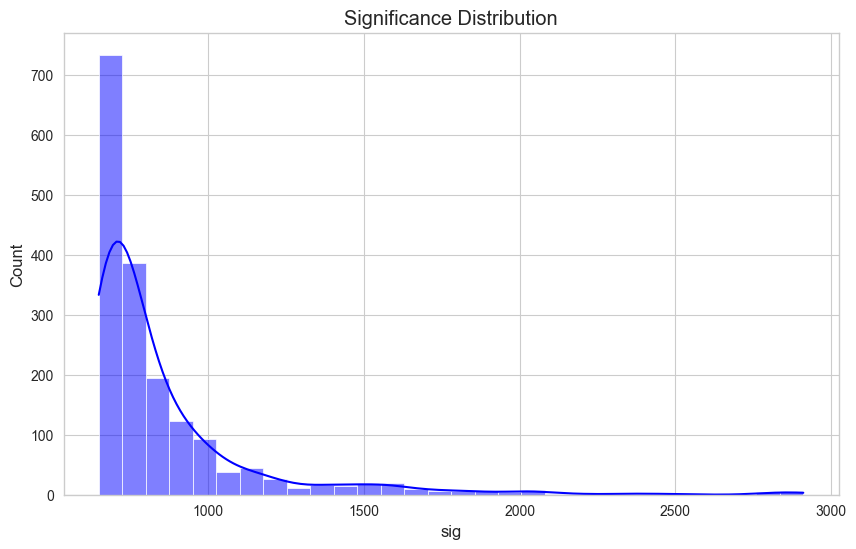

In [26]:
plt.figure(figsize=(10, 6))

sns.histplot(earth_df["sig"], bins=30, kde=True, color="blue")
plt.title("Significance Distribution")
plt.show()


DEPTH DISTRIBUTION

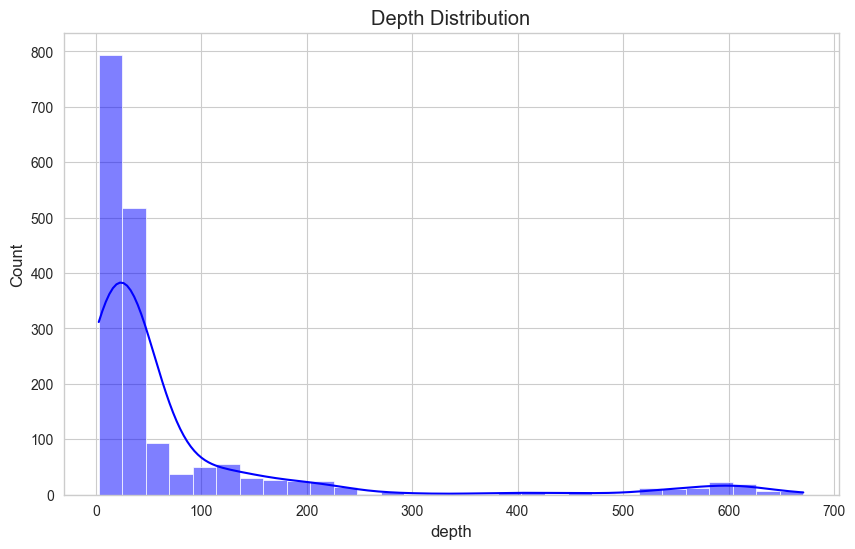

In [27]:
plt.figure(figsize=(10, 6))

sns.histplot(earth_df["depth"], bins=30, kde=True, color="blue")

plt.title("Depth Distribution")
plt.show()

MAGNITUDE vs TSUNAMI

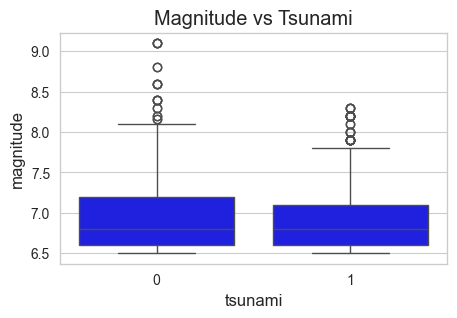

In [28]:
plt.figure(figsize=(5, 3))

sns.boxplot(x="tsunami", y="magnitude", data=earth_df, color='blue')
plt.title("Magnitude vs Tsunami")
plt.show()

DEFINING THE INPUTS AND THE OUTPUT

In [59]:
features = [
    "cdi",
    "mmi",
    "tsunami",
    "sig",
    "nst",
    "dmin",
    "gap",
    "depth",
    "latitude",
    "longitude"
]

X = earth_df[features]
y = earth_df["magnitude"]

print(X.shape)

(1782, 10)


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (1425, 10)
Testing Shape: (357, 10)


SCALING THE FEATURES

In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling Completed")

Scaling Completed


LINEAR REGRESSION

In [32]:
lr = LinearRegression()

lr.fit(
    X_train_scaled,
    y_train
)
lr_pred = lr.predict(
    X_test_scaled
)

print("Linear Regression Trained")

Linear Regression Trained


LASSO REGRESSION

In [33]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)
lasso_pred = lasso_model.predict(X_test_scaled)
print("Lasso Regression Trained")

Lasso Regression Trained


RIDGE REGRESSION

In [34]:
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
print("Ridge Regression Trained")

Ridge Regression Trained


DECISION TREE REGRESSOR

In [35]:
dt = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

dt.fit(
    X_train,
    y_train
)
dt_pred = dt.predict(
    X_test
)

print("Decision Tree Trained")

Decision Tree Trained


RANDOM FOREST REGRESSOR

In [36]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)
rf_pred = rf.predict(
    X_test
)

print("Random Forest Trained")

Random Forest Trained


TESTING SKEWNESS

In [63]:
print("CHECK 1:")
for i in range(10):
    pred = rf.predict([X_test.iloc[i]])
    print("Actual:", y_test.iloc[i], "Predicted:", pred[0])

print("\nCHECK 2:")
preds = rf.predict(X_test)

print(preds.min())
print(preds.max())
print(preds.mean())

CHECK 1:
Actual: 6.5 Predicted: 6.5
Actual: 6.9 Predicted: 7.127912992435584
Actual: 8.2 Predicted: 7.874712888922601
Actual: 6.5 Predicted: 6.5
Actual: 7.1 Predicted: 7.099333333333295
Actual: 6.6 Predicted: 7.484878813652517
Actual: 6.5 Predicted: 6.505333333333333
Actual: 6.7 Predicted: 6.700000000000031
Actual: 6.6 Predicted: 6.599999999999966
Actual: 7.3 Predicted: 7.423372195952748

CHECK 2:
6.5
8.470070255931782
6.95177259242484


In [ ]:
print(
    rf.predict(
        pd.DataFrame(
            {
                "cdi": [8],
                "mmi": [8],
                "tsunami": [1],
                "sig": [1500],
                "nst": [300],
                "dmin": [0.1],
                "gap": [20],
                "depth": [50],
                "latitude": [35],
                "longitude": [70],
            }
        )
    )
)


In [37]:
def evaluate_model(
        y_true,
        y_pred,
        model_name):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )
    r2 = r2_score(
        y_true,
        y_pred
    )
    return {
        "Model": model_name,
        "MAE": round(mae,4),
        "RMSE": round(rmse,4),
        "R2": round(r2,4)
    }

MODEL COMPARISON

In [38]:
results = []

results.append(
    evaluate_model(
        y_test,
        lr_pred,
        "Linear Regression"
    )
)
results.append(
    evaluate_model(
        y_test,
        lasso_pred,
        "Lasso Regression"
    )
)
results.append(
    evaluate_model(
        y_test,
        ridge_pred,
        "Ridge Regression"
    )
)
results.append(
    evaluate_model(
        y_test,
        dt_pred,
        "Decision Tree"
    )
)
results.append(
    evaluate_model(
        y_test,
        rf_pred,
        "Random Forest"
    )
)

comparison_df = pd.DataFrame(results)
comparison_df.head()

,Model,MAE,RMSE,R2
0,Linear Regression,0.2902,0.4019,0.1431
1,Lasso Regression,0.3065,0.4004,0.1497
2,Ridge Regression,0.2902,0.4019,0.1432
3,Decision Tree,0.0734,0.1923,0.8038
4,Random Forest,0.0758,0.1568,0.8696


TRAINING SCORE VS TEST SCORE

In [39]:
scores = []


def train_test_scores(name, model, X_train_data, X_test_data, y_train, y_test):
    train_score = model.score(X_train_data, y_train)  # R² on training

    test_score = model.score(X_test_data, y_test)  # R² on testing

    return {
        "Model Name": name,
        "Training R²": round(train_score, 4),
        "Testing R²": round(test_score, 4),
        "Difference": round(abs(train_score - test_score), 4),
    }


# Linear Regression
scores.append(
    train_test_scores("Linear Regression", lr, X_train_scaled, X_test_scaled, y_train, y_test)
)
# Ridge Regression
scores.append(
    train_test_scores("Ridge Regression", ridge_model, X_train_scaled, X_test_scaled, y_train, y_test)
    )
# Lasso Regression
scores.append(
    train_test_scores("Lasso Regression", lasso_model, X_train_scaled, X_test_scaled, y_train, y_test)
)
# Decision Tree
scores.append(
    train_test_scores("Decision Tree", dt, X_train, X_test, y_train, y_test)
)
# Random Forest
scores.append(
    train_test_scores("Random Forest", rf, X_train, X_test, y_train, y_test)
)

scores_df = pd.DataFrame(scores)
scores_df.head()


,Model Name,Training R²,Testing R²,Difference
0,Linear Regression,0.3842,0.1431,0.2410
1,Ridge Regression,0.3842,0.1432,0.2410
2,Lasso Regression,0.2559,0.1497,0.1062
3,Decision Tree,0.9544,0.8038,0.1506
4,Random Forest,0.9734,0.8696,0.1038


BIAS VARIANCE VISUALIZATION

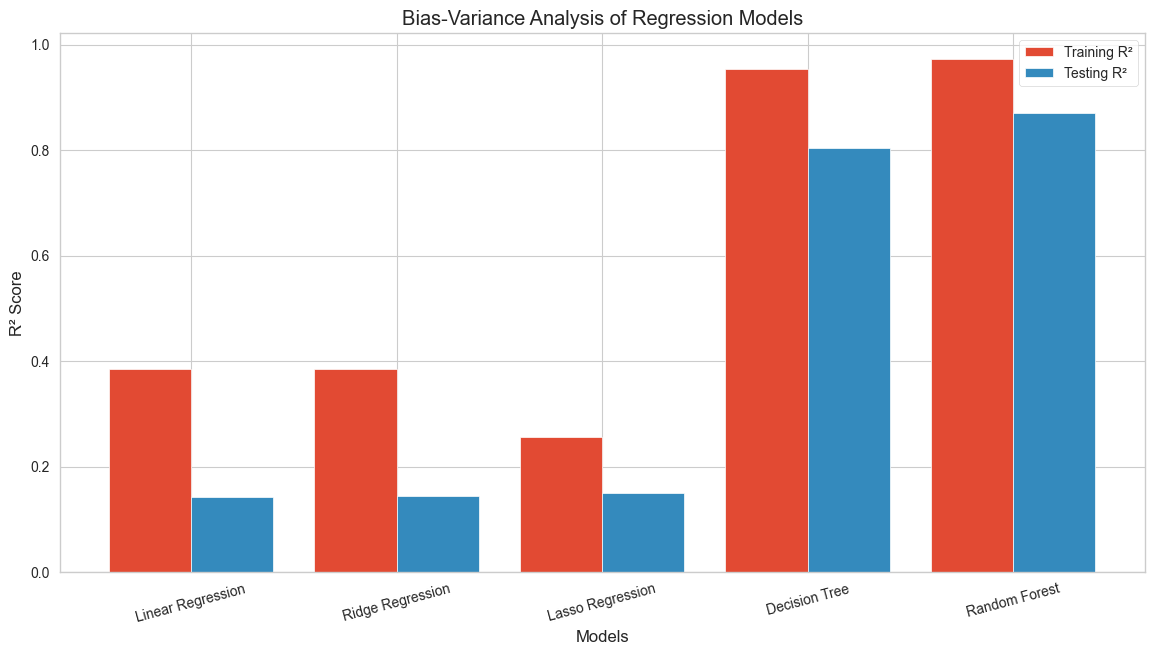

In [40]:
models = scores_df["Model Name"]

train_scores = scores_df["Training R²"]
test_scores = scores_df["Testing R²"]

x = np.arange(len(models))
plt.figure(figsize=(14, 7))

plt.bar(x - 0.2, train_scores, width=0.4, label="Training R²")
plt.bar(x + 0.2, test_scores, width=0.4, label="Testing R²")

plt.xticks(x, models, rotation=15)

plt.ylabel("R² Score")
plt.xlabel("Models")

plt.title("Bias-Variance Analysis of Regression Models")
plt.legend()
plt.grid(True)
plt.show()


RANDOM FOREST (ACTUAL VS PREDICTED)

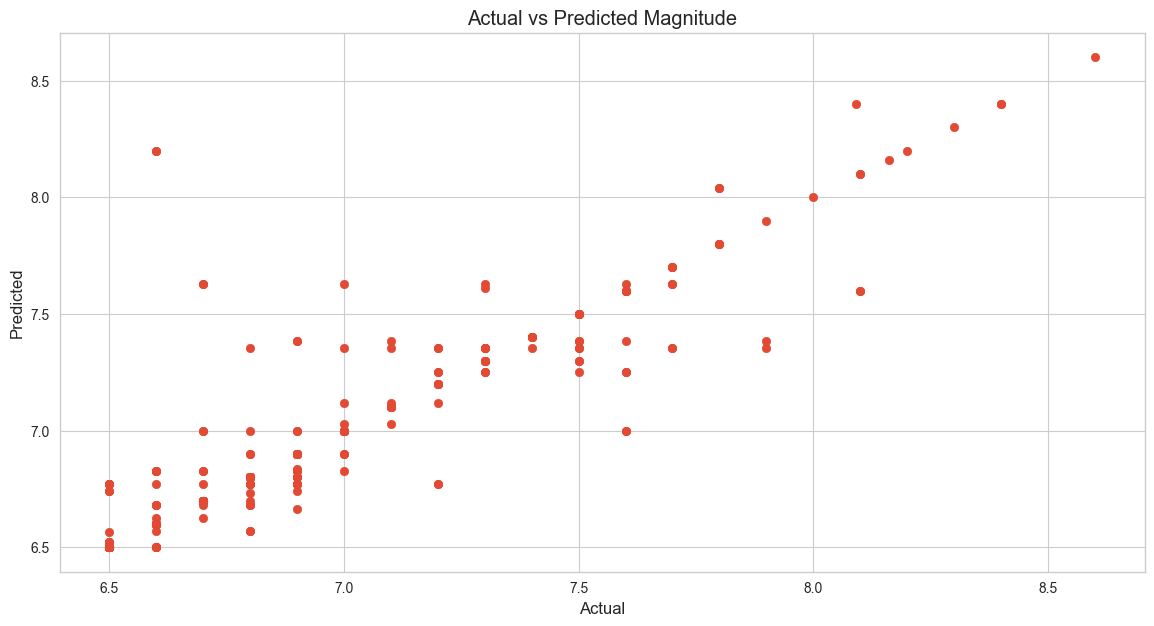

In [41]:
plt.figure(figsize=(14,7))

plt.scatter(
    y_test,
    dt_pred
)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Magnitude")

plt.show()

RESIDUAK ANALYSIS

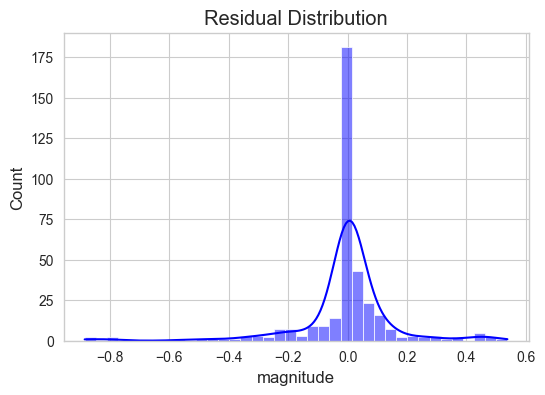

In [42]:
residuals = y_test - rf_pred

plt.figure(figsize=(6, 4))

sns.histplot(
    residuals,
    kde = True,
    color = 'blue'
)
plt.title("Residual Distribution")

plt.show()

RANDOM FOREST FEATURE IMPORTANCE

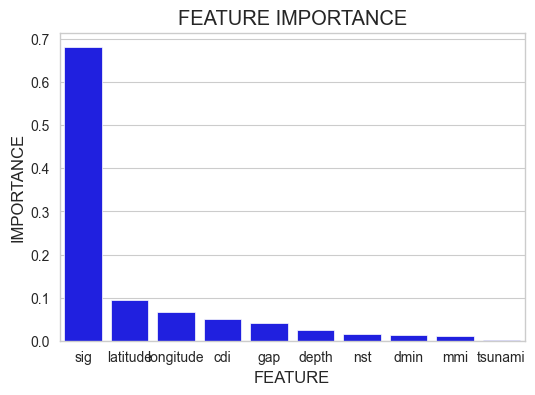

In [43]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)
plt.figure(figsize=(6, 4))
sns.barplot(
    data=importance,
    x = 'Feature',
    y = 'Importance',
    color = 'blue'
)
plt.title('FEATURE IMPORTANCE')
plt.xlabel('FEATURE')
plt.ylabel('IMPORTANCE')
plt.show()

EARTHQUAKE HOTSPOT DETECTION 

In [44]:
kmeans = KMeans(
    n_clusters=10,
    random_state=42
)

earth_df["Cluster"] = kmeans.fit_predict(
    earth_df[
        ["latitude","longitude"]
    ]
)

print("Hotspots Created")
print(earth_df['Cluster'].head(10))

Hotspots Created
0    3
1    5
2    4
3    1
4    1
5    5
6    6
7    6
8    5
9    3
Name: Cluster, dtype: int32


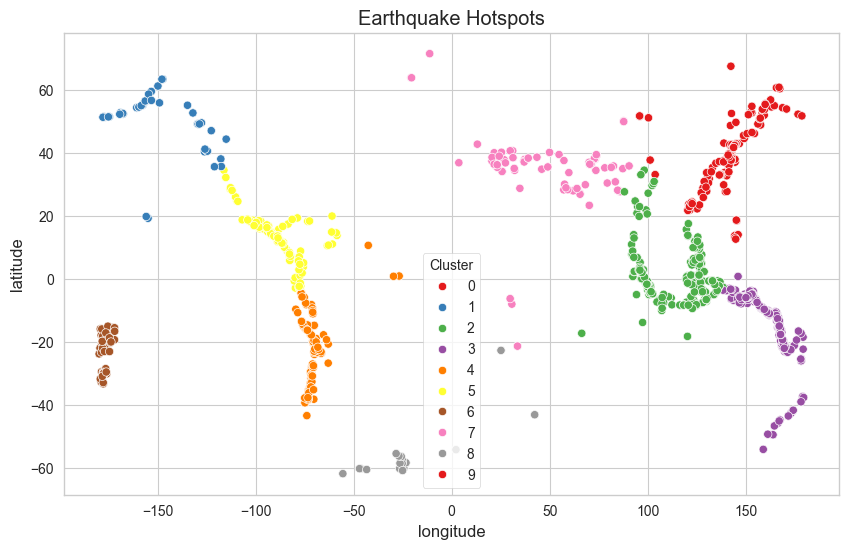

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=earth_df["longitude"],
    y=earth_df["latitude"],
    hue=earth_df["Cluster"],
    palette="Set1"
)

plt.title("Earthquake Hotspots")

plt.show()

MAGNITUDE TO ALERT PREDICTION

In [46]:
def magnitude_to_alert(magnitude):

    if magnitude < 5:
        return "GREEN"

    elif magnitude < 6:
        return "YELLOW"

    elif magnitude < 7:
        return "ORANGE"

    else:
        return "RED"

SAMPLE PREDICTION

In [47]:
sample = pd.DataFrame({

    "cdi":[8],
    "mmi":[8],
    "tsunami":[1],
    "sig":[900],
    "nst":[120],
    "dmin":[1.5],
    "gap":[20],
    "depth":[15],
    "latitude":[35],
    "longitude":[73]

})

predicted_magnitude = rf.predict(sample)[0]

predicted_alert = magnitude_to_alert(
    predicted_magnitude
)

print(
    "Predicted Magnitude:",
    round(predicted_magnitude,2)
)

print(
    "Predicted Alert:",
    predicted_alert
)

Predicted Magnitude: 6.85
Predicted Alert: ORANGE


SAVING MODEL

In [ ]:
joblib.dump(
    rf,
    "magnitude_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
